#Tạo Thư Mục


In [2]:
from pathlib import Path

cwd = Path.cwd().resolve()
BASE = cwd.parent if (cwd / "data").exists() is False and (cwd.parent / "data").exists() else cwd

dirs = ["data/raw", "data/processed", "notebooks", "src", "results", "report"]
for d in dirs:
    (BASE / d).mkdir(parents=True, exist_ok=True)
print("✅ Da tao cau truc thu muc")

requirements = """datasets
pandas
matplotlib
seaborn
"""
(BASE / "requirements.txt").write_text(requirements, encoding="utf-8")
print("✅ Da tao requirements.txt")

✅ Da tao cau truc thu muc
✅ Da tao requirements.txt


#CÀI ĐẶT THƯ VIỆN

In [3]:
# Import thu vien
import pandas as pd
import json
from pathlib import Path
from datasets import load_dataset

cwd = Path.cwd().resolve()
BASE = cwd.parent if (cwd / "data").exists() is False and (cwd.parent / "data").exists() else cwd
(BASE / "data" / "raw").mkdir(parents=True, exist_ok=True)

print("Dang tai tap 'train' cua bo du lieu MBPP...")

dataset_train = load_dataset("google-research-datasets/mbpp", split="train")
df_train = pd.DataFrame(dataset_train)

file_path = BASE / "data" / "raw" / "mbpp_train.json"
df_train.to_json(file_path, orient="records", indent=2)

print(f"Thanh cong! Da load {len(df_train)} bai tap.")
print(f"Cac bai tap co ID tu: {df_train['task_id'].min()} den {df_train['task_id'].max()}")
print(f"Du lieu da duoc luu tai: {file_path}")

df_train.head(3)

e:\Bao Cao Ha Dung\Tuan 2\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dang tai tap 'train' cua bo du lieu MBPP...


Thanh cong! Da load 374 bai tap.
Cac bai tap co ID tu: 601 den 974
Du lieu da duoc luu tai: E:\Bao Cao Ha Dung\Tuan 2\Project\data\raw\mbpp_train.json


,task_id,text,code,test_list,test_setup_code,challenge_test_list
0,601,Write a function to find the longest chain whi...,"class Pair(object): \r\n\tdef __init__(self, a...","[assert max_chain_length([Pair(5, 24), Pair(15...",,[]
1,602,Write a python function to find the first repe...,"def first_repeated_char(str1):\r\n for index,...","[assert first_repeated_char(""abcabc"") == ""a"", ...",,[]
2,603,Write a function to get a lucid number smaller...,def get_ludic(n):\r\n\tludics = []\r\n\tfor i ...,"[assert get_ludic(10) == [1, 2, 3, 5, 7], asse...",,[]


#KIỂM TRA VÀ LÀM SẠCH DỮ LIỆU

In [4]:
from pathlib import Path

df = df_train.copy()
cwd = Path.cwd().resolve()
BASE = cwd.parent if (cwd / "data").exists() is False and (cwd.parent / "data").exists() else cwd

(BASE / "data" / "processed").mkdir(parents=True, exist_ok=True)

print("=== KIEM TRA DU LIEU ===")
print(f"So bai: {len(df)}")
print(f"So dong trung (task_id): {df['task_id'].duplicated().sum()}")
print(f"\nGia tri null:\n{df.isnull().sum()}")

df = df.drop_duplicates(subset="task_id")
df = df[df["text"].str.strip() != ""]
df = df[df["code"].str.strip() != ""]

df["desc_length"] = df["text"].apply(len)
df["num_tests"] = df["test_list"].apply(len)

file_path = BASE / "data" / "processed" / "mbpp_train_clean.json"
df.to_json(file_path, orient="records", indent=2)

print(f"\n✅ Sau lam sach: {len(df)} bai")
print(f"✅ Da luu file thanh cong tai: {file_path}")

=== KIEM TRA DU LIEU ===
So bai: 374
So dong trung (task_id): 0

Gia tri null:
task_id                0
text                   0
code                   0
test_list              0
test_setup_code        0
challenge_test_list    0
dtype: int64

✅ Sau lam sach: 374 bai
✅ Da luu file thanh cong tai: E:\Bao Cao Ha Dung\Tuan 2\Project\data\processed\mbpp_train_clean.json


#BẢNG THỐNG KÊ DỮ LIỆU

In [5]:

# Bản sao của dữ liệu gốc tránh làm hỏng
df = df_train.copy()

# Xoá các bài trùng lặp ID
df = df.drop_duplicates(subset='task_id')
# Xoá dòng đề bài bị trống
df = df[df['text'].str.strip() != '']
# Xoá dòng không có code mẫu
df = df[df['code'].str.strip() != '']
df['desc_length'] = df['text'].apply(len)
df['num_tests']   = df['test_list'].apply(len)


print("=== BẢNG THỐNG KÊ ===")
stats = {
    'Số bài toán':          len(df),
    'Số test trung bình':   round(df['num_tests'].mean(), 2),
    'Min test/bài':         df['num_tests'].min(),
    'Max test/bài':         df['num_tests'].max(),
    'Độ dài desc TB (ký tự)': round(df['desc_length'].mean(), 1),
    'Độ dài desc min':      df['desc_length'].min(),
    'Độ dài desc max':      df['desc_length'].max(),
}

for k, v in stats.items():
    print(f" {k}: {v}")

=== BẢNG THỐNG KÊ ===
 Số bài toán: 374
 Số test trung bình: 3.0
 Min test/bài: 3
 Max test/bài: 3
 Độ dài desc TB (ký tự): 78.4
 Độ dài desc min: 38
 Độ dài desc max: 249


#BIỂU ĐỒ

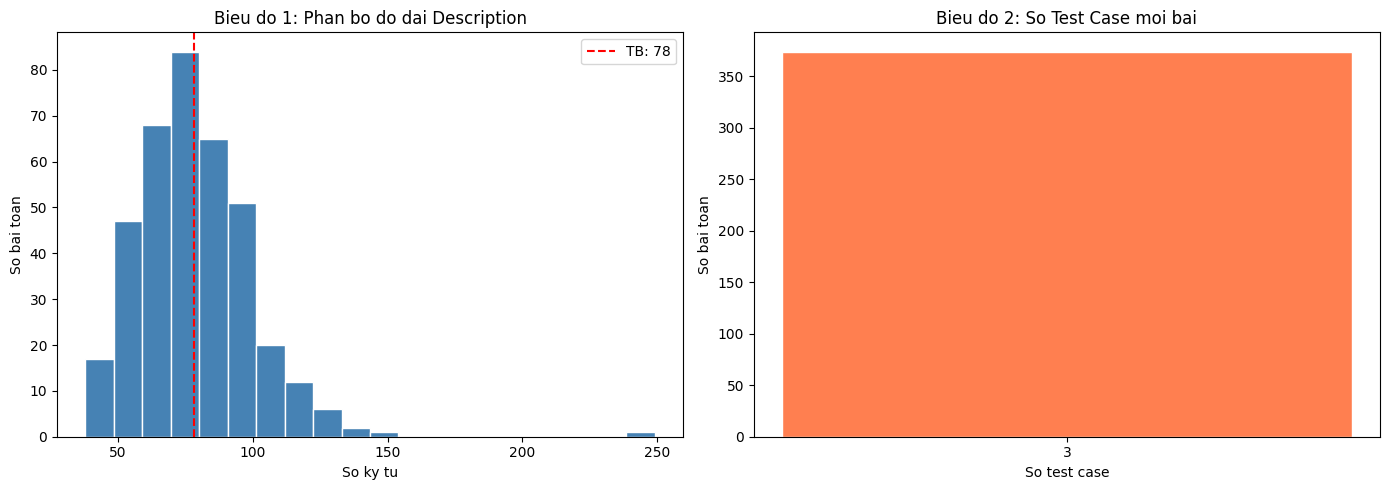

✅ Da luu bieu do vao results/


In [6]:
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
matplotlib.rcParams["font.family"] = "DejaVu Sans"

cwd = Path.cwd().resolve()
BASE = cwd.parent if (cwd / "data").exists() is False and (cwd.parent / "data").exists() else cwd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["desc_length"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Bieu do 1: Phan bo do dai Description")
axes[0].set_xlabel("So ky tu")
axes[0].set_ylabel("So bai toan")
axes[0].axvline(df["desc_length"].mean(), color="red", linestyle="--", label=f"TB: {df['desc_length'].mean():.0f}")
axes[0].legend()

test_counts = df["num_tests"].value_counts().sort_index()
axes[1].bar(test_counts.index.astype(str), test_counts.values, color="coral", edgecolor="white")
axes[1].set_title("Bieu do 2: So Test Case moi bai")
axes[1].set_xlabel("So test case")
axes[1].set_ylabel("So bai toan")

plt.tight_layout()
plt.savefig(BASE / "results" / "data_analysis.png", dpi=150)
plt.show()
print("✅ Da luu bieu do vao results/")